In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn

  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)

   ---------------------------------------- 0/3 [contourpy]
   ---------------------------------------- 0/3 [contourpy]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [mat


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Load Dataset & Preprocess
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("E:\\ML\\market_demand_analysis_of_e_commerce\\Dataset\\indian_ecommerce_pricing_revenue_growth_36_months (1).csv")
df['order_date'] = pd.to_datetime(df['order_date'])
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+']
)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Global Style
# ─────────────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
PALETTE = ["#3d72b8", "#63b393", "#c9663c", "#8e5db5", "#b8873d",
           "#5a9e7a", "#b84d6b", "#4d9ab8"]
plt.rcParams.update({
    "figure.facecolor": "#f9f9f9",
    "axes.facecolor":   "#ffffff",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})

print("Global plotting style set up.")

Dataset loaded: 30,600 rows × 17 columns

Global plotting style set up.


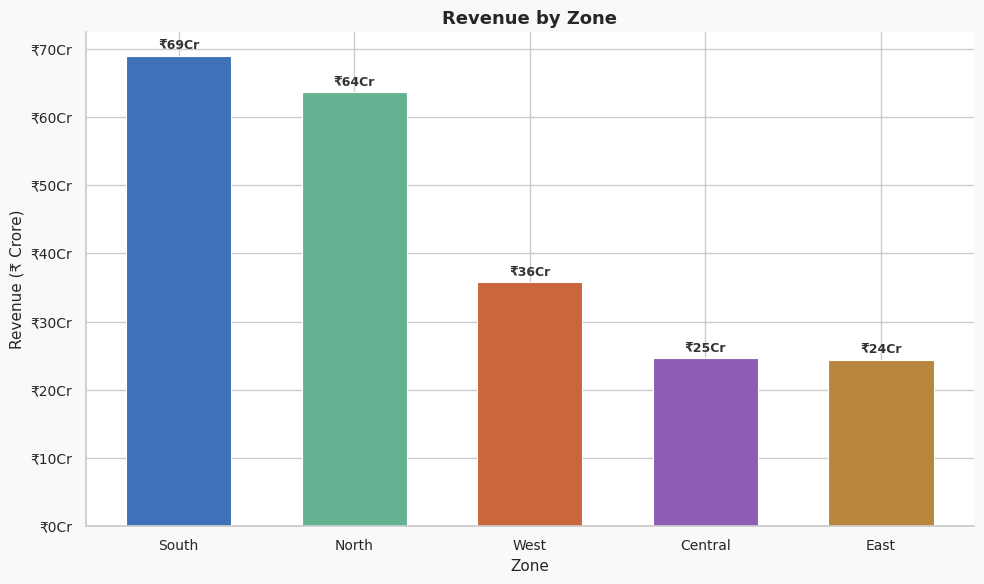

In [4]:
plt.figure(figsize=(10, 6))
zone_rev = (df.groupby("zone")["revenue"].sum() / 1e7).sort_values(ascending=False)
bars = plt.bar(zone_rev.index, zone_rev.values, color=PALETTE[:len(zone_rev)],
               edgecolor="white", linewidth=0.8, width=0.6)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"₹{bar.get_height():.0f}Cr", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#333")
plt.title("Revenue by Zone")
plt.ylabel("Revenue (₹ Crore)")
plt.xlabel("Zone")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}Cr"))
plt.tight_layout()
plt.show()

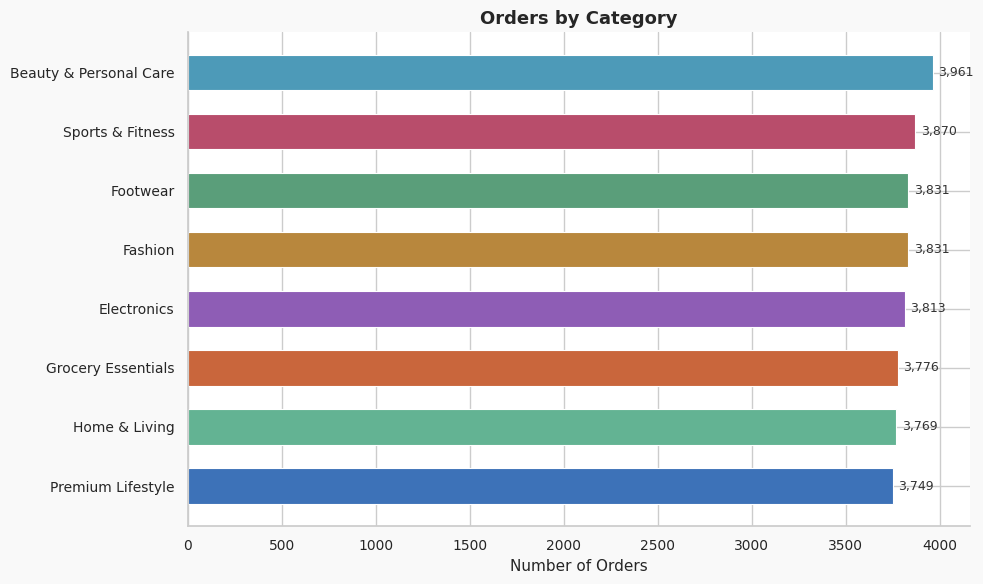

In [5]:
plt.figure(figsize=(10, 6))
cat_counts = df["category"].value_counts().sort_values()
plt.barh(cat_counts.index, cat_counts.values, color=PALETTE[:len(cat_counts)],
         edgecolor="white", linewidth=0.8, height=0.6)
for i, v in enumerate(cat_counts.values):
    plt.text(v + 30, i, f"{v:,}", va="center", fontsize=9, color="#333")
plt.title("Orders by Category")
plt.xlabel("Number of Orders")
plt.ylabel("")
plt.tight_layout()
plt.show()

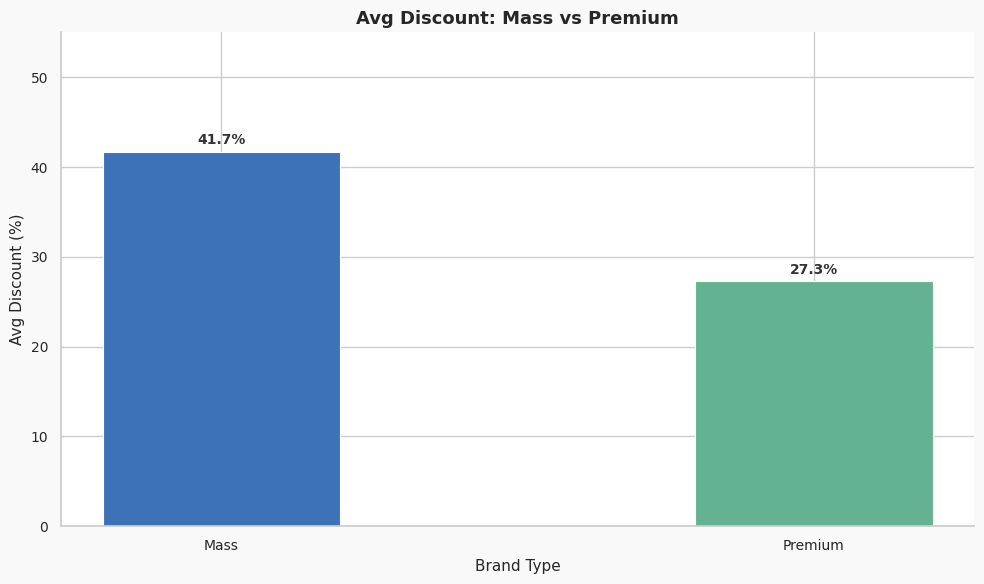

In [6]:
plt.figure(figsize=(10, 6))
brand_disc = df.groupby("brand_type")["discount_percent"].mean()
colors_b = [PALETTE[0], PALETTE[1]]
bars = plt.bar(brand_disc.index, brand_disc.values, color=colors_b,
                edgecolor="white", linewidth=0.8, width=0.4)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#333")
plt.title("Avg Discount: Mass vs Premium")
plt.ylabel("Avg Discount (%)")
plt.xlabel("Brand Type")
plt.ylim(0, 55)
plt.tight_layout()
plt.show()

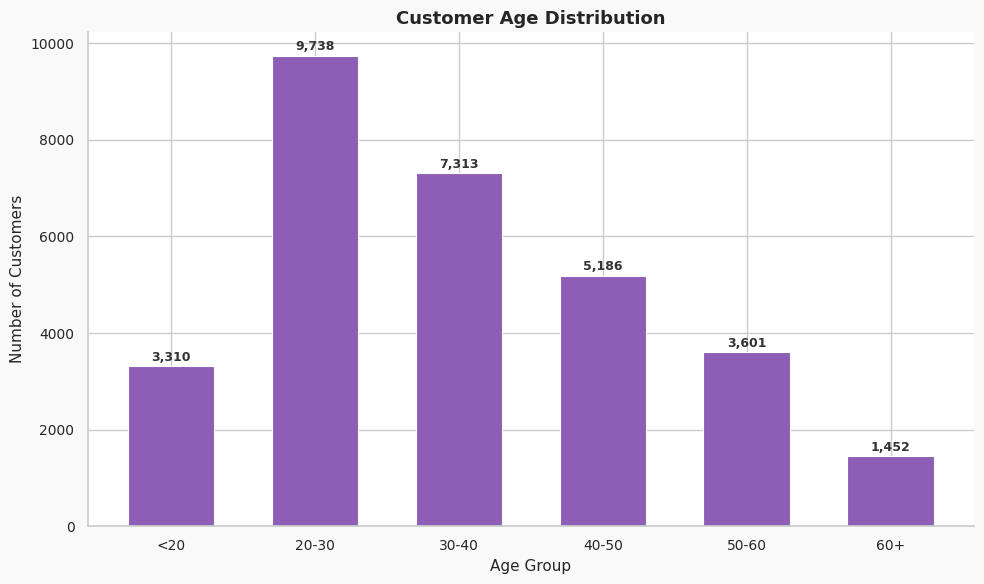

In [7]:
plt.figure(figsize=(10, 6))
age_dist = df["age_group"].value_counts().sort_index()
bars = plt.bar(age_dist.index.astype(str), age_dist.values,
                color=PALETTE[3], edgecolor="white", linewidth=0.8, width=0.6)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{bar.get_height():,}", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#333")
plt.title("Customer Age Distribution")
plt.ylabel("Number of Customers")
plt.xlabel("Age Group")
plt.tight_layout()
plt.show()

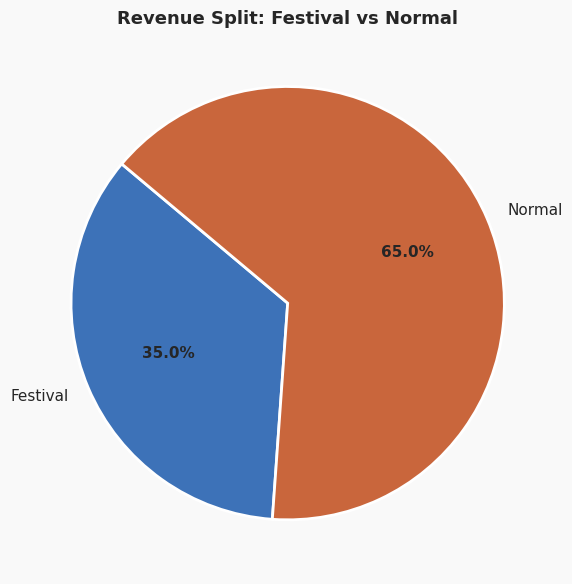

In [8]:
plt.figure(figsize=(10, 6))
event_rev = df.groupby("sales_event")["revenue"].sum()
wedges, texts, autotexts = plt.pie(
    event_rev.values,
    labels=event_rev.index,
    autopct="%1.1f%%",
    colors=[PALETTE[0], PALETTE[2]],
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontweight("bold")
plt.title("Revenue Split: Festival vs Normal")
plt.tight_layout()
plt.show()

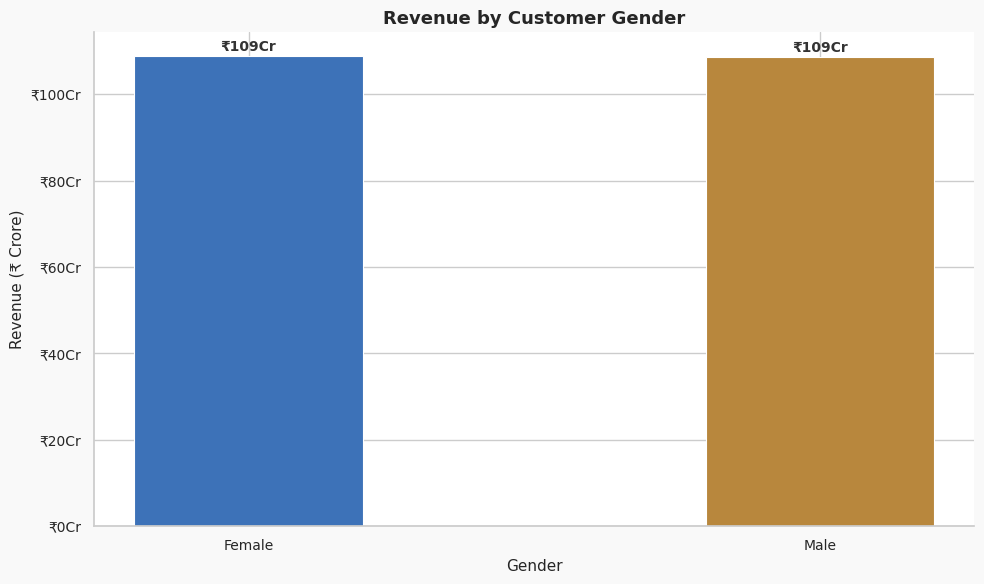

In [9]:
plt.figure(figsize=(10, 6))
gender_rev = (df.groupby("customer_gender")["revenue"].sum() / 1e7).sort_values(ascending=False)
bars = plt.bar(gender_rev.index, gender_rev.values,
                color=[PALETTE[0], PALETTE[4]], edgecolor="white",
                linewidth=0.8, width=0.4)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"₹{bar.get_height():.0f}Cr", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#333")
plt.title("Revenue by Customer Gender")
plt.ylabel("Revenue (₹ Crore)")
plt.xlabel("Gender")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}Cr"))
plt.tight_layout()
plt.show()

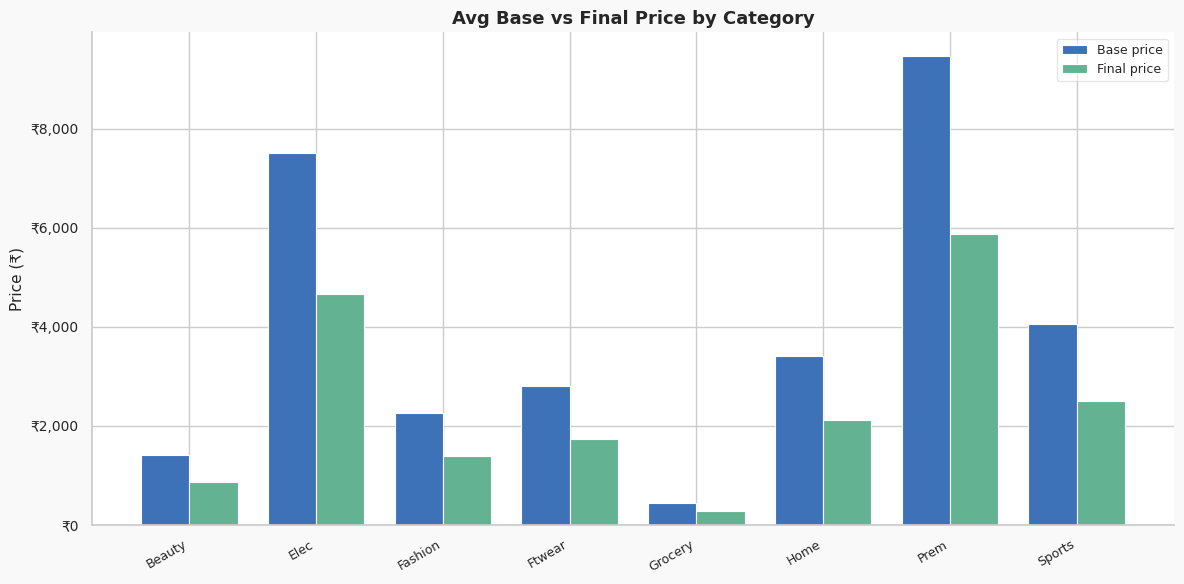

In [10]:
plt.figure(figsize=(12, 6))
price_comp = df.groupby("category")[["base_price", "final_price"]].mean().reset_index()
x = range(len(price_comp))
width = 0.38
plt.bar([i - width / 2 for i in x], price_comp["base_price"],
        width=width, label="Base price", color=PALETTE[0],
        edgecolor="white", linewidth=0.8)
plt.bar([i + width / 2 for i in x], price_comp["final_price"],
        width=width, label="Final price", color=PALETTE[1],
        edgecolor="white", linewidth=0.8)
short_labels = ["Beauty", "Elec", "Fashion", "Ftwear",
                "Grocery", "Home", "Prem", "Sports"]
plt.xticks(list(x), short_labels, rotation=30, ha="right", fontsize=9)
plt.title("Avg Base vs Final Price by Category")
plt.ylabel("Price (₹)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
plt.legend(fontsize=9, framealpha=0.5)
plt.tight_layout()
plt.show()